# Laboratorio 4: Generación de variables aleatorias continuas
**Simulación Computacional · Universidad de los Llanos**  
**Santiago Barrera Meza · Código 160005004**

Desarrollo de la guía FO-DOC-112, práctica 04, del 25 de septiembre de 2024.

**Ejecución:** ejecutar todas las celdas en orden en Google Colab o Jupyter con NumPy, SciPy y Matplotlib.
Las salidas y gráficas están guardadas. Todas las muestras se generan desde un generador congruencial mixto implementado aquí; no se usan generadores de distribuciones de NumPy o SciPy.

## 1. Objetivos
Generar variables continuas mediante transformada inversa, aceptación-rechazo y método polar; comparar muestras con densidades teóricas; simular procesos de Poisson homogéneos y no homogéneos. Se incluyen ejemplos complementarios de exponencial, Gamma y normal estándar para cubrir los objetivos generales de la guía.

## 2. Consulta previa

### ¿Qué es una variable aleatoria?
Es una función medible que asigna un número real a cada resultado de un experimento aleatorio: $X:\Omega\to\mathbb R$. Ejemplo: el tiempo que transcurre hasta la siguiente llegada.

### ¿Qué es una distribución de probabilidad?
Es la ley que asigna probabilidades a los valores o conjuntos de valores de una variable aleatoria. Su función de distribución acumulada es $F_X(x)=P(X\le x)$; es no decreciente, continua por la derecha y tiene límites 0 y 1 en los extremos de la recta real.

### Diferencia entre distribuciones discretas y continuas
Una variable discreta toma valores en un conjunto finito o numerable, con función de masa $p(x)=P(X=x)$ y $\sum_xp(x)=1$. Una variable absolutamente continua tiene densidad $f(x)\ge0$, $\int_{-\infty}^{\infty}f(x)\,dx=1$ y $P(a<X\le b)=\int_a^bf(x)\,dx$. En este último caso $P(X=x)=0$: la densidad en un punto no es una probabilidad. En esta práctica, «continua» se usa en el sentido de absolutamente continua.

### Distribución exponencial
Con tasa $\lambda>0$, $f(x)=\lambda e^{-\lambda x}$ para $x\ge0$ y cero en otro caso. Su acumulada es $F(x)=1-e^{-\lambda x}$ para $x\ge0$, su media $1/\lambda$ y su varianza $1/\lambda^2$. Modela tiempos entre llegadas de un proceso de Poisson homogéneo y tiene la propiedad de falta de memoria.

### Distribución Gamma y sus parámetros
Con forma $k>0$ y tasa $\lambda>0$,
$$f(x)=\frac{\lambda^k}{\Gamma(k)}x^{k-1}e^{-\lambda x},\quad x>0.$$
Su media es $k/\lambda$ y su varianza $k/\lambda^2$. La escala alternativa es $\theta=1/\lambda$. Si $k$ es entero, es la suma de $k$ exponenciales independientes de igual tasa (distribución Erlang). Para $k=1$ se obtiene la exponencial.

### Distribución normal estándar y sus parámetros
Es $Z\sim N(0,1)$: media $\mu=0$, varianza $\sigma^2=1$ y densidad $\phi(z)=e^{-z^2/2}/\sqrt{2\pi}$ para $z\in\mathbb R$. Una normal general se obtiene como $X=\mu+\sigma Z$, $\sigma>0$.

### Procesos de Poisson homogéneos y no homogéneos
Ambos son procesos de conteo con $N(0)=0$ e incrementos independientes. En el homogéneo la tasa $\lambda$ es constante y $N(t+h)-N(t)\sim\operatorname{Poisson}(\lambda h)$; sus incrementos son estacionarios y sus tiempos entre llegadas son exponenciales independientes de tasa $\lambda$.
En el no homogéneo la intensidad $\lambda(t)$ depende del tiempo y
$$N(b)-N(a)\sim\operatorname{Poisson}\left(\int_a^b\lambda(s)\,ds\right).$$
En general sus incrementos no son estacionarios ni sus tiempos entre llegadas son exponenciales idénticamente distribuidos. La diferencia esencial es la tasa constante frente a una intensidad variable.

## 3. Fundamento teórico
**Transformada inversa:** si $U\sim U(0,1)$, entonces $F^{-1}(U)$ tiene acumulada $F$, usando la inversa generalizada si es necesario.  
**Aceptación-rechazo:** proponer $Y\sim g$ y aceptar si $U\le f(Y)/(Mg(Y))$, con $Mg\ge f$. La probabilidad de aceptación es $1/M$.  
**Método polar:** proponer $V_1,V_2$ uniformes en $(-1,1)$ hasta obtener $0<S=V_1^2+V_2^2<1$ y devolver $V_i\sqrt{-2\log(S)/S}$.  
**Poisson:** acumular tiempos exponenciales hasta superar el horizonte. Para intensidad variable se puede usar rechazo temporal (adelgazamiento) con una cota de la intensidad.

## 4. Equipos, materiales y reproducibilidad
Computador con Python/Jupyter o Google Colab. Semillas fijas, aritmética entera en el generador y 1000 observaciones por distribución de la sección 5.1. Los parámetros no especificados en el enunciado se indican en cada ejemplo.

In [1]:
%matplotlib inline
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, integrate, special

N = 1000
plt.rcParams.update({'figure.figsize': (9, 4), 'axes.grid': True,
                     'grid.alpha': 0.22, 'font.size': 11})
np.set_printoptions(precision=5, suppress=True)

class GCM:
    """Congruencial mixto de 64 bits; uniformes estrictamente entre 0 y 1."""
    m = 2**64
    a = 6364136223846793005
    c = 1442695040888963407

    def __init__(self, semilla):
        self.estado = int(semilla) % self.m

    def uniforme(self):
        self.estado = (self.a * self.estado + self.c) % self.m
        # Los 52 bits superiores evitan usar directamente los bits bajos del GCM.
        # El punto medio asegura 0 < U < 1 incluso en coma flotante.
        return ((self.estado >> 12) + 0.5) / 2**52

    def uniformes(self, n):
        return np.array([self.uniforme() for _ in range(n)])

def exponencial(rng, tasa):
    if not np.isfinite(tasa) or tasa <= 0:
        raise ValueError('La tasa debe ser finita y positiva.')
    return -math.log1p(-rng.uniforme()) / tasa

def comparar(x, pdf, limites, titulo):
    rejilla = np.linspace(*limites, 500)
    fig, ax = plt.subplots()
    ax.hist(x, bins=30, density=True, color='#43a6c6', alpha=0.65,
            edgecolor='white', label=f'Muestra (n={len(x)})')
    ax.plot(rejilla, pdf(rejilla), color='#b83b44', lw=2.3, label='Densidad teórica')
    ax.set(xlabel='x', ylabel='Densidad', title=titulo)
    ax.legend(); fig.tight_layout(); plt.show()

def resumen(nombre, x, media, varianza):
    error_mc = math.sqrt(varianza / len(x))
    print(f'{nombre}: n={len(x)}, media={x.mean():.5f} (teórica {media:.5f}), '
          f'varianza muestral={x.var(ddof=1):.5f} (teórica {varianza:.5f})')
    print(f'Error estándar teórico de la media: {error_mc:.5f}; '
          f'diferencia en errores estándar: {(x.mean()-media)/error_mc:.2f}')

## 5. Procedimiento y metodología
### Generador base: periodo y diagnósticos
La recurrencia es $S_{n+1}=(aS_n+c)\bmod m$. Cumple las condiciones de Hull-Dobell: $c$ es impar, por lo que $\gcd(c,2^{64})=1$; el único factor primo de $m$ es 2 y divide $a-1$; además $a-1$ es divisible por 4. El periodo de los estados es $2^{64}$ para cualquier semilla.

Un periodo largo **no prueba independencia ni calidad universal**. Se examinan uniformidad con chi-cuadrado y Kolmogorov-Smirnov, rachas respecto a 0.5, correlaciones seriales y un gráfico de pares. Las pruebas son diagnósticos aproximados para una secuencia determinista; no convierten al generador en una fuente de azar verdadero. A nivel 0.05, un valor p pequeño sería una señal para investigar; no rechazar tampoco demuestra aleatoriedad. Se usan estados distintos para los ejemplos, sin afirmar independencia matemática entre semillas.

Uniformes: media=0.49892 (0.5), varianza=0.08320 (1/12)
Chi-cuadrado: estadístico=5.9240, p=0.7475
KS: D=0.0059, p=0.8748
Rachas: R=5044, z=0.8604, p aproximado=0.3895
Correlación a rezago 1: 0.00511
Correlación a rezago 2: -0.00172
Correlación a rezago 5: 0.01293
Correlación a rezago 10: -0.00831


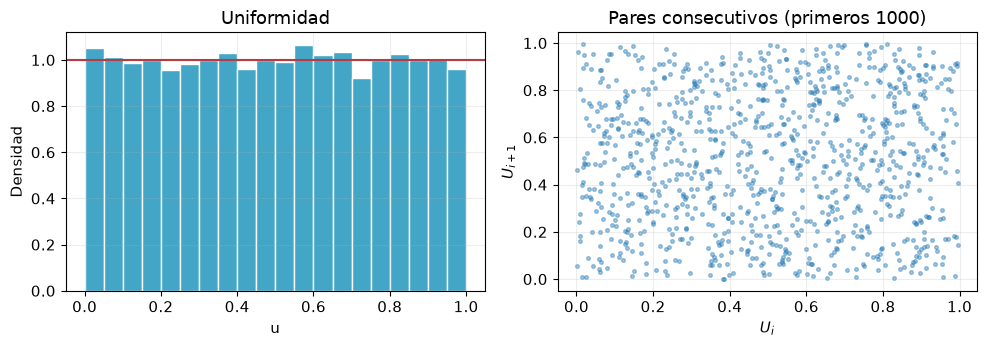

In [2]:
assert math.gcd(GCM.c, GCM.m) == 1 and (GCM.a-1) % 4 == 0
u = GCM(160005004).uniformes(10000)
assert np.all((u > 0) & (u < 1))
chi = stats.chisquare(np.histogram(u, bins=np.linspace(0, 1, 11))[0])
ks = stats.kstest(u, 'uniform')
b = u >= 0.5
n1, n0 = int(b.sum()), int((~b).sum())
rachas = 1 + int(np.count_nonzero(b[1:] != b[:-1]))
er = 1 + 2*n1*n0/len(u)
vr = 2*n1*n0*(2*n1*n0-len(u))/(len(u)**2*(len(u)-1))
zr = (rachas-er)/math.sqrt(vr)
print(f'Uniformes: media={u.mean():.5f} (0.5), varianza={u.var(ddof=1):.5f} (1/12)')
print(f'Chi-cuadrado: estadístico={chi.statistic:.4f}, p={chi.pvalue:.4f}')
print(f'KS: D={ks.statistic:.4f}, p={ks.pvalue:.4f}')
print(f'Rachas: R={rachas}, z={zr:.4f}, p aproximado={2*stats.norm.sf(abs(zr)):.4f}')
for lag in (1, 2, 5, 10):
    print(f'Correlación a rezago {lag}: {np.corrcoef(u[:-lag], u[lag:])[0,1]:.5f}')
fig, axs = plt.subplots(1, 2, figsize=(10, 3.6))
axs[0].hist(u, bins=20, density=True, color='#43a6c6', edgecolor='white')
axs[0].axhline(1, color='#b83b44'); axs[0].set(title='Uniformidad', xlabel='u', ylabel='Densidad')
axs[1].scatter(u[:999], u[1:1000], s=7, alpha=0.4)
axs[1].set(title='Pares consecutivos (primeros 1000)', xlabel='$U_i$', ylabel='$U_{i+1}$')
fig.tight_layout(); plt.show()

### 5.1. Generación de variables aleatorias continuas
#### a. Densidad $f(x)=e^x/(e-1)$, $0\le x\le1$
Fuera de ese intervalo la densidad es cero. Integramos:
$$F(x)=\frac{e^x-1}{e-1},\quad 0\le x\le1.$$
La acumulada vale 0 a la izquierda y 1 a la derecha del soporte. Al resolver $u=F(x)$:
$$\boxed{X=\log(1+(e-1)U).}$$
La integral de la densidad es 1. Además,
$$E[X]=\frac1{e-1},\qquad E[X^2]=\frac{e-2}{e-1},\qquad
\operatorname{Var}(X)=\frac{e-2}{e-1}-\frac1{(e-1)^2}.$$

5.1.a: n=1000, media=0.57252 (teórica 0.58198), varianza muestral=0.08028 (teórica 0.07933)
Error estándar teórico de la media: 0.00891; diferencia en errores estándar: -1.06
Primeros 10: [0.95165 0.18033 0.15305 0.21047 0.37578 0.11706 0.45626 0.84215 0.37311
 0.8894 ]


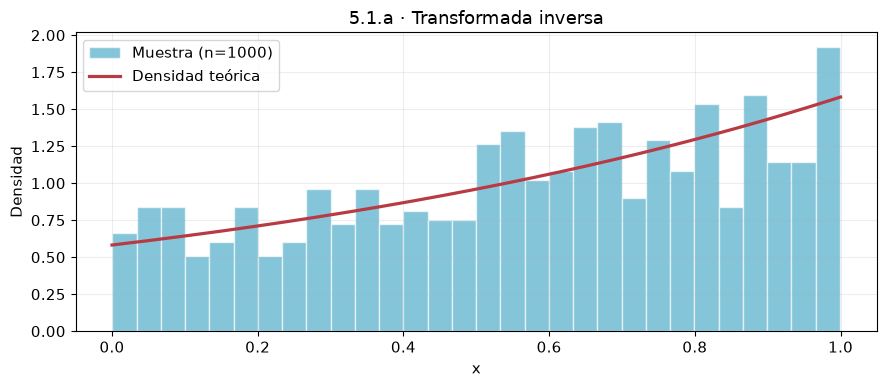

In [3]:
def generar_a(rng, n):
    return np.log1p(np.expm1(1.0) * rng.uniformes(n))

def pdf_a(x):
    x = np.asarray(x)
    return np.where((x >= 0) & (x <= 1), np.exp(x)/np.expm1(1.0), 0.0)

def cdf_a(x):
    return np.expm1(np.clip(x, 0, 1))/np.expm1(1.0)

xa = generar_a(GCM(4101), N)
ma = 1/math.expm1(1)
va = (math.e-2)/math.expm1(1)-ma**2
resumen('5.1.a', xa, ma, va)
print('Primeros 10:', xa[:10])
comparar(xa, pdf_a, (0, 1), '5.1.a · Transformada inversa')

#### b. Densidad por tramos
$$f(x)=\begin{cases}(x-2)/2,&2\le x\le3,\\(2-x/3)/2=(6-x)/6,&3<x\le6,\\0,&\text{en otro caso.}\end{cases}$$
Las áreas de ambos tramos son $1/4$ y $3/4$, así que la integral es 1. La densidad es triangular con mínimo 2, moda 3 y máximo 6.

Se implementa **aceptación-rechazo** para practicar este método: $Y=2+4U_1$ es uniforme en $[2,6]$, $g=1/4$, $\max f=1/2$ y $M=2$. Aceptar cuando $U_2\le2f(Y)$. Su aceptación teórica es $1/2$.

Para verificar también se deriva la acumulada y su inversa:
$$F(x)=\begin{cases}0,&x<2,\\(x-2)^2/4,&2\le x\le3,\\1-(6-x)^2/12,&3<x\le6,\\1,&x>6,\end{cases}$$
$$F^{-1}(u)=\begin{cases}2+2\sqrt{u},&u\le1/4,\\6-\sqrt{12(1-u)},&u>1/4.\end{cases}$$
Sus momentos son $E[X]=11/3$ y $\operatorname{Var}(X)=13/18$.

5.1.b: n=1000, media=3.64609 (teórica 3.66667), varianza muestral=0.72872 (teórica 0.72222)
Error estándar teórico de la media: 0.02687; diferencia en errores estándar: -0.77
Propuestas: 2042; aceptación: 0.4897 (teórica 0.5)
Primeros 10: [3.0813  2.55715 4.7091  5.82739 2.78963 5.04497 3.94492 3.45344 3.155
 2.79809]


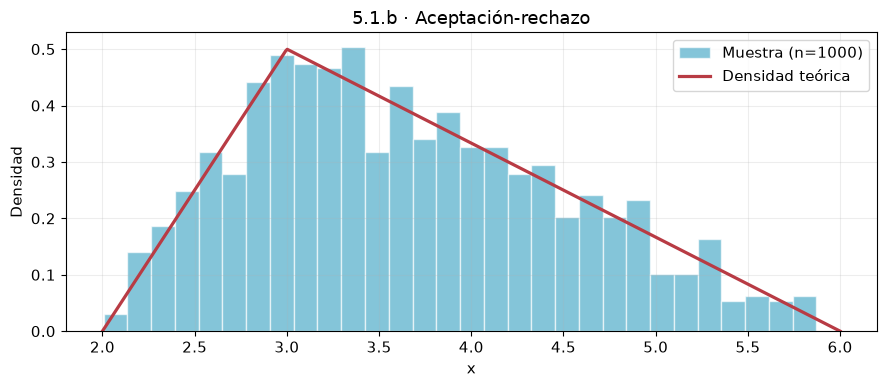

In [4]:
def pdf_b(x):
    x = np.asarray(x)
    return np.where((x >= 2) & (x <= 3), (x-2)/2,
                    np.where((x > 3) & (x <= 6), (6-x)/6, 0.0))

def cdf_b(x):
    x = np.clip(x, 2, 6)
    return np.where(x <= 3, (x-2)**2/4, 1-(6-x)**2/12)

def generar_b(rng, n):
    valores, intentos = [], 0
    while len(valores) < n:
        y = 2 + 4*rng.uniforme()
        fy = (y-2)/2 if y <= 3 else (6-y)/6
        intentos += 1
        if rng.uniforme() <= 2*fy:
            valores.append(y)
    return np.array(valores), intentos

def inversa_b(u):
    return np.where(u <= 0.25, 2+2*np.sqrt(u), 6-np.sqrt(12*(1-u)))

xb, intentos_b = generar_b(GCM(4102), N)
resumen('5.1.b', xb, 11/3, 13/18)
print(f'Propuestas: {intentos_b}; aceptación: {N/intentos_b:.4f} (teórica 0.5)')
print('Primeros 10:', xb[:10])
comparar(xb, pdf_b, (2, 6), '5.1.b · Aceptación-rechazo')

#### c. Acumulada $F(x)=(x^2+x)/2$, $0\le x\le1$
Se extiende con 0 para $x<0$ y 1 para $x>1$. Resolver $x^2+x-2u=0$ da la raíz válida:
$$\boxed{X=\frac{-1+\sqrt{1+8U}}2.}$$
La raíz negativa queda fuera del soporte. La densidad que debe superponerse al histograma es la **derivada** de la acumulada: $f(x)=x+1/2$ en $[0,1]$. Sus momentos son $E[X]=7/12$, $E[X^2]=5/12$ y $\operatorname{Var}(X)=11/144$.

5.1.c: n=1000, media=0.59426 (teórica 0.58333), varianza muestral=0.07601 (teórica 0.07639)
Error estándar teórico de la media: 0.00874; diferencia en errores estándar: 1.25
Primeros 10: [0.71682 0.95288 0.28399 0.17026 0.15437 0.96736 0.40679 0.29104 0.98463
 0.46238]


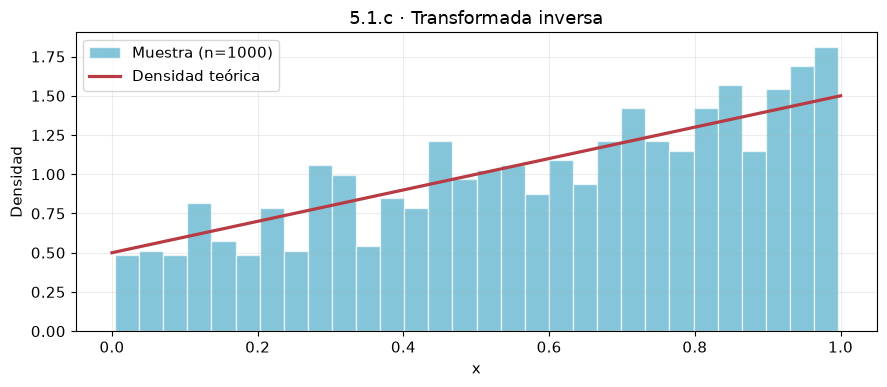

In [5]:
def generar_c(rng, n):
    return (np.sqrt(1+8*rng.uniformes(n))-1)/2

def pdf_c(x):
    x = np.asarray(x)
    return np.where((x >= 0) & (x <= 1), x+0.5, 0.0)

def cdf_c(x):
    x = np.clip(x, 0, 1)
    return (x*x+x)/2

xc = generar_c(GCM(4103), N)
resumen('5.1.c', xc, 7/12, 11/144)
print('Primeros 10:', xc[:10])
comparar(xc, pdf_c, (0, 1), '5.1.c · Transformada inversa')

#### d. Weibull: $F(x)=1-\exp(-\alpha x^\beta)$, $x>0$
Para $\alpha,\beta>0$ y $F(x)=0$ si $x\le0$:
$$\boxed{X=\left(\frac{-\log(1-U)}\alpha\right)^{1/\beta}.}$$
La densidad es $f(x)=\alpha\beta x^{\beta-1}e^{-\alpha x^\beta}$, $x>0$.
En esta parametrización $\beta$ es la forma y la escala es $\alpha^{-1/\beta}$; $\alpha$ no es directamente la escala.
$$E[X]=\alpha^{-1/\beta}\Gamma(1+1/\beta),$$
$$\operatorname{Var}(X)=\alpha^{-2/\beta}\left[\Gamma(1+2/\beta)-\Gamma(1+1/\beta)^2\right].$$
La guía no da valores numéricos: se eligen **$\alpha=2$, $\beta=1.5$** para el ejemplo y se deja una función parametrizable.

5.1.d: n=1000, media=0.54619 (teórica 0.56869), varianza muestral=0.13799 (teórica 0.14909)
Error estándar teórico de la media: 0.01221; diferencia en errores estándar: -1.84
Primeros 10: [1.37568 0.34919 0.25356 0.12156 0.49427 1.07157 0.80001 1.09002 0.34567
 0.13048]


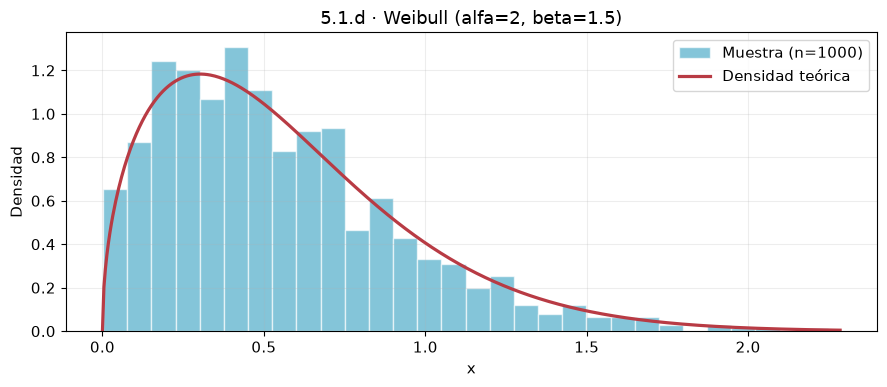

In [6]:
def generar_weibull(rng, n, alfa, beta):
    if not np.isfinite(alfa) or not np.isfinite(beta) or alfa <= 0 or beta <= 0:
        raise ValueError('alfa y beta deben ser finitos y positivos.')
    return (-np.log1p(-rng.uniformes(n))/alfa)**(1/beta)

alfa_w, beta_w = 2.0, 1.5
xd = generar_weibull(GCM(4104), N, alfa_w, beta_w)
def pdf_d(x):
    x = np.asarray(x)
    z = np.maximum(x, 0)
    return np.where(x > 0, alfa_w*beta_w*z**(beta_w-1)*np.exp(-alfa_w*z**beta_w), 0.0)
def cdf_d(x):
    return -np.expm1(-alfa_w*np.maximum(x, 0)**beta_w)
md_w = alfa_w**(-1/beta_w)*special.gamma(1+1/beta_w)
vd_w = alfa_w**(-2/beta_w)*(special.gamma(1+2/beta_w)-special.gamma(1+1/beta_w)**2)
resumen('5.1.d', xd, md_w, vd_w)
print('Primeros 10:', xd[:10])
comparar(xd, pdf_d, (0, max(xd.max(), (-math.log(0.001)/alfa_w)**(1/beta_w))),
         '5.1.d · Weibull (alfa=2, beta=1.5)')

#### Verificación conjunta de 5.1
Se comprueba la normalización de las densidades, los soportes, la cantidad de observaciones y las inversas. Se reporta KS como diagnóstico de ajuste con parámetros fijados previamente. Las muestras completas quedan en `muestras_51`, una matriz de 1000 filas y cuatro columnas (a, b, c, d), disponible al volver a ejecutar el notebook.

In [7]:
muestras_51 = np.column_stack([xa, xb, xc, xd])
assert muestras_51.shape == (1000, 4) and np.isfinite(muestras_51).all()
assert ((xa >= 0) & (xa <= 1)).all()
assert ((xb >= 2) & (xb <= 6)).all()
assert ((xc >= 0) & (xc <= 1)).all() and (xd > 0).all()
for etiqueta, muestra, pdf, cdf, lo, hi in [
    ('a', xa, pdf_a, cdf_a, 0, 1), ('b', xb, pdf_b, cdf_b, 2, 6),
    ('c', xc, pdf_c, cdf_c, 0, 1), ('d', xd, pdf_d, cdf_d, 0, np.inf)]:
    integral = integrate.quad(lambda x: float(pdf(x)), lo, hi)[0]
    assert abs(integral-1) < 1e-7
    prueba = stats.kstest(muestra, cdf)
    print(f'{etiqueta}: integral={integral:.8f}; KS D={prueba.statistic:.5f}, p={prueba.pvalue:.5f}')
q = np.linspace(0.0001, 0.9999, 1000)
assert np.allclose(cdf_a(np.log1p(math.expm1(1)*q)), q)
assert np.allclose(cdf_b(inversa_b(q)), q)
assert np.allclose(cdf_c((np.sqrt(1+8*q)-1)/2), q)
assert np.allclose(cdf_d((-np.log1p(-q)/alfa_w)**(1/beta_w)), q)
print('Verificaciones de soporte, tamaño, normalización e inversas: correctas.')

a: integral=1.00000000; KS D=0.03036, p=0.30906
b: integral=1.00000000; KS D=0.01718, p=0.92435
c: integral=1.00000000; KS D=0.02683, p=0.45963
d: integral=1.00000000; KS D=0.03486, p=0.17183
Verificaciones de soporte, tamaño, normalización e inversas: correctas.


### 5.2. Generando procesos de Poisson
#### a. Proceso homogéneo durante las primeras $T$ unidades
Iniciar $t=0$, generar $E=-\log(1-U)/\lambda$ y actualizar $t\leftarrow t+E$. Registrar $t$ si $t\le T$ y repetir; detenerse al exceder $T$. Se devuelve la lista de llegadas, y su longitud es $N(T)$. El último tiempo que excede el horizonte no es un evento del intervalo.

Se eligen **$T=10$ y $\lambda=3$**, pues el enunciado solicita un algoritmo general sin fijarlos. Entonces $N(10)\sim\operatorname{Poisson}(30)$, con media y varianza 30. Una trayectoria particular no tiene por qué contener exactamente 30 llegadas.

N(10) = 25; tiempos de llegada:
[0.18468 0.90816 1.07836 1.19775 1.39561 1.40833 1.97805 2.39412 3.43877
 3.44571 3.4774  4.26682 5.40111 5.49177 5.74212 5.76517 6.67772 7.25153
 7.48667 8.2801  8.84396 8.84989 9.3314  9.3851  9.96059]


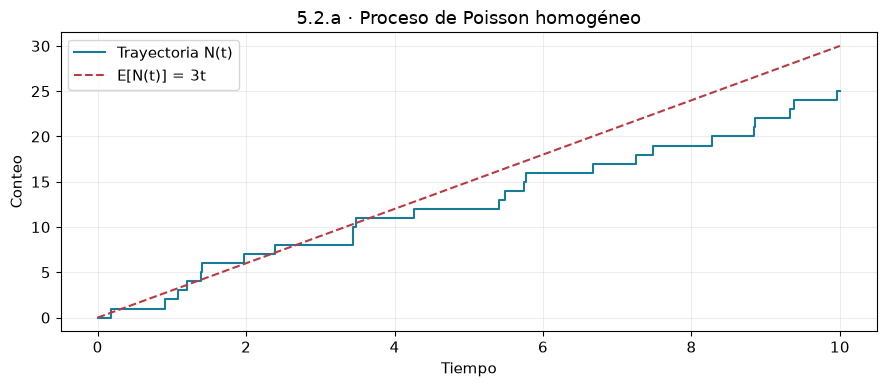

N(10), 3000 réplicas: n=3000, media=30.01133 (teórica 30.00000), varianza muestral=31.02155 (teórica 30.00000)
Error estándar teórico de la media: 0.10000; diferencia en errores estándar: 0.11


In [8]:
def poisson_homogeneo(rng, tasa, T):
    if not np.isfinite(T) or T < 0 or not np.isfinite(tasa) or tasa <= 0:
        raise ValueError('Se requiere T finito >= 0 y tasa finita > 0.')
    t, llegadas = 0.0, []
    while T > 0:
        t += exponencial(rng, tasa)
        if t > T:
            break
        llegadas.append(t)
    return np.array(llegadas)

T, tasa = 10.0, 3.0
lh = poisson_homogeneo(GCM(4201), tasa, T)
print(f'N({T:g}) = {len(lh)}; tiempos de llegada:')
print(lh)
fig, ax = plt.subplots()
ax.step(np.r_[0, lh, T], np.r_[0, np.arange(1, len(lh)+1), len(lh)],
        where='post', label='Trayectoria N(t)', color='#187c99')
ax.plot([0, T], [0, tasa*T], '--', color='#b83b44', label='E[N(t)] = 3t')
ax.set(xlabel='Tiempo', ylabel='Conteo', title='5.2.a · Proceso de Poisson homogéneo')
ax.legend(); fig.tight_layout(); plt.show()

R = 3000
rng_h = GCM(4202)
conteos_h = np.array([len(poisson_homogeneo(rng_h, tasa, T)) for _ in range(R)])
resumen('N(10), 3000 réplicas', conteos_h, tasa*T, tasa*T)
assert np.all(np.diff(lh) > 0) and np.all((lh > 0) & (lh <= T))
assert len(poisson_homogeneo(GCM(1), tasa, 0)) == 0

#### b. Variable aleatoria Coxian
Para etapas independientes con tasas $\lambda_i>0$ y decisiones de continuación independientes de los tiempos:
1. Iniciar $X=0$.
2. En la etapa $i$, sumar $-\log(1-U_i)/\lambda_i$ a $X$.
3. Si $i=k$, terminar. Si $i<k$, continuar a $i+1$ cuando $V_i<\alpha_i$; de lo contrario terminar.

La guía enumera $\alpha_i$ hasta $k$, pero después de la etapa $k$ no hay otra etapa. Por ello solo se necesitan $k-1$ probabilidades; $\alpha_k$ no afecta el tiempo total en este modelo finito.

Si $p_i=\prod_{j=1}^{i-1}\alpha_j$ es la probabilidad de alcanzar la etapa $i$, con $p_1=1$,
$$E[X]=\sum_{i=1}^k\frac{p_i}{\lambda_i},\qquad
E[X^2]=2\sum_{i=1}^k\frac{p_i}{\lambda_i^2}
+2\sum_{i<j}\frac{p_j}{\lambda_i\lambda_j}.$$
El factor $p_j$ en los productos cruzados aparece porque alcanzar $j$ implica haber alcanzado $i$.

Ejemplo elegido: $k=3$, tasas $(2,3,4)$ y continuaciones $(0.8,0.6)$. Así $p=(1,0.8,0.48)$ y $E[X]=0.886666\ldots$. Se simulan 1000 trabajos.

Coxian: n=1000, media=0.91168 (teórica 0.88667), varianza muestral=0.47776 (teórica 0.41827)
Error estándar teórico de la media: 0.02045; diferencia en errores estándar: 1.22
Probabilidad de terminar en etapas 1, 2 y 3: [0.2  0.32 0.48]
Frecuencia observada por etapa final: [0.185 0.315 0.5  ]
Primeros 10 tiempos: [0.36222 1.29004 0.74932 0.67614 0.56011 0.84495 0.18735 1.42176 1.14701
 0.55458]


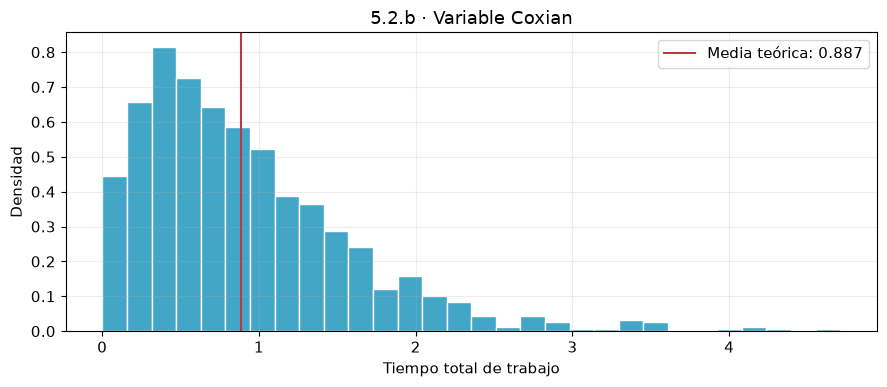

In [9]:
def coxian(rng, tasas, alfas):
    tasas, alfas = np.asarray(tasas, float), np.asarray(alfas, float)
    if tasas.ndim != 1 or len(tasas) == 0 or not np.isfinite(tasas).all() or (tasas <= 0).any():
        raise ValueError('Las tasas deben formar un vector no vacío de valores positivos finitos.')
    if alfas.shape != (len(tasas)-1,) or not np.isfinite(alfas).all() or ((alfas < 0) | (alfas > 1)).any():
        raise ValueError('Se necesitan k-1 probabilidades entre 0 y 1.')
    total = 0.0
    for i, lam in enumerate(tasas):
        total += exponencial(rng, lam)
        if i == len(tasas)-1 or rng.uniforme() >= alfas[i]:
            return total, i+1

tasas_c, alfas_c = np.array([2., 3., 4.]), np.array([0.8, 0.6])
pc = np.r_[1., np.cumprod(alfas_c)]
mc = np.sum(pc/tasas_c)
ec2 = 2*np.sum(pc/tasas_c**2) + 2*sum(
    pc[j]/(tasas_c[i]*tasas_c[j]) for i in range(3) for j in range(i+1, 3))
vc = ec2-mc**2
rng_c = GCM(4203)
trabajos = np.array([coxian(rng_c, tasas_c, alfas_c) for _ in range(N)])
x_cox = trabajos[:, 0]
resumen('Coxian', x_cox, mc, vc)
print('Probabilidad de terminar en etapas 1, 2 y 3:', np.r_[pc[:-1]*(1-alfas_c), pc[-1]])
print('Frecuencia observada por etapa final:', np.bincount(trabajos[:, 1].astype(int), minlength=4)[1:]/N)
print('Primeros 10 tiempos:', x_cox[:10])
fig, ax = plt.subplots()
ax.hist(x_cox, bins=30, density=True, color='#43a6c6', edgecolor='white')
ax.axvline(mc, color='#b83b44', label=f'Media teórica: {mc:.3f}')
ax.set(xlabel='Tiempo total de trabajo', ylabel='Densidad', title='5.2.b · Variable Coxian')
ax.legend(); fig.tight_layout(); plt.show()
assert coxian(GCM(7), [2, 3], [0])[1] == 1
assert coxian(GCM(7), [2, 3], [1])[1] == 2
assert coxian(GCM(7), [2], [])[1] == 1

### 5.3. Generando procesos de Poisson no homogéneos
La intensidad de la guía es
$$\lambda(t)=\begin{cases}t/5,&0<t<5,\\1+5(t-5),&5<t<10.\end{cases}$$
Se extiende por continuidad en $0,5,10$; el valor en un punto aislado no altera las probabilidades. En $[0,10]$ la cota es $\lambda^*=26$.

**Algoritmo de adelgazamiento:** generar candidatos de un Poisson homogéneo de tasa 26; aceptar cada candidato $t\le10$ con probabilidad $\lambda(t)/26$. Detenerse al superar 10. El proceso aceptado tiene la intensidad solicitada.

La intensidad acumulada es
$$\Lambda(t)=\int_0^t\lambda(s)\,ds=
\begin{cases}t^2/10,&0\le t\le5,\\2.5+(t-5)+2.5(t-5)^2,&5<t\le10.\end{cases}$$
Por tanto $\Lambda(5)=2.5$ y $\Lambda(10)=70$; $N(10)\sim\operatorname{Poisson}(70)$. Se esperan 2.5 eventos en la primera mitad y 67.5 en la segunda. El número esperado de candidatos es 260, y la razón entre los números esperados de aceptados y candidatos es $70/260\approx0.26923$.

N(10)=64; candidatos=274; aceptación=0.2336
Llegadas en [0, 10]:
[2.62175 2.94647 5.43126 5.98705 6.48379 6.52568 6.67792 6.87537 7.21312
 7.21521 7.22488 7.26986 7.41296 7.51219 7.51337 7.60788 7.85128 7.86278
 7.95997 7.96562 8.03195 8.03531 8.1512  8.17492 8.29305 8.36832 8.37654
 8.44567 8.47045 8.54468 8.5727  8.59928 8.7083  8.74557 8.76495 8.76676
 8.81478 8.82511 8.83828 8.92792 8.95352 8.96883 8.96887 9.01107 9.02484
 9.02768 9.06198 9.11996 9.17607 9.20814 9.21353 9.25103 9.33783 9.54497
 9.55931 9.61194 9.62417 9.73252 9.73984 9.78591 9.94748 9.94986 9.97121
 9.99845]


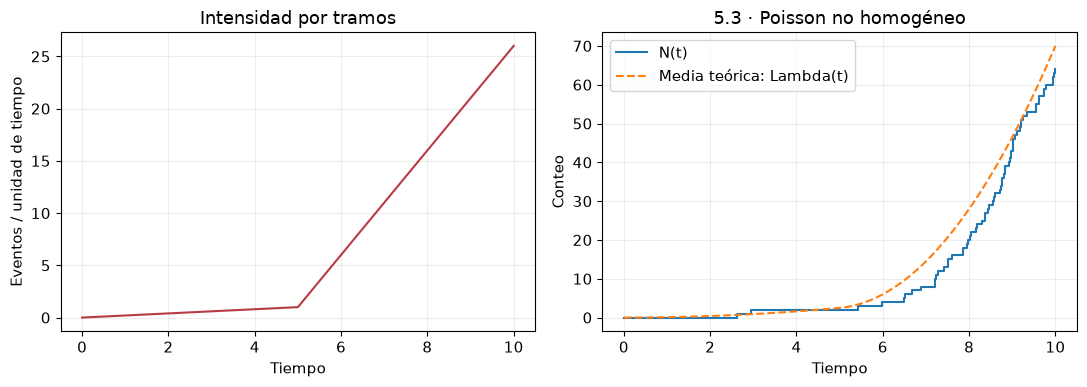

N(10), 3000 réplicas: n=3000, media=69.88100 (teórica 70.00000), varianza muestral=71.23859 (teórica 70.00000)
Error estándar teórico de la media: 0.15275; diferencia en errores estándar: -0.78
Media N(5)=2.4817 (teórica 2.5)
Media N(10)-N(5)=67.3993 (teórica 67.5)


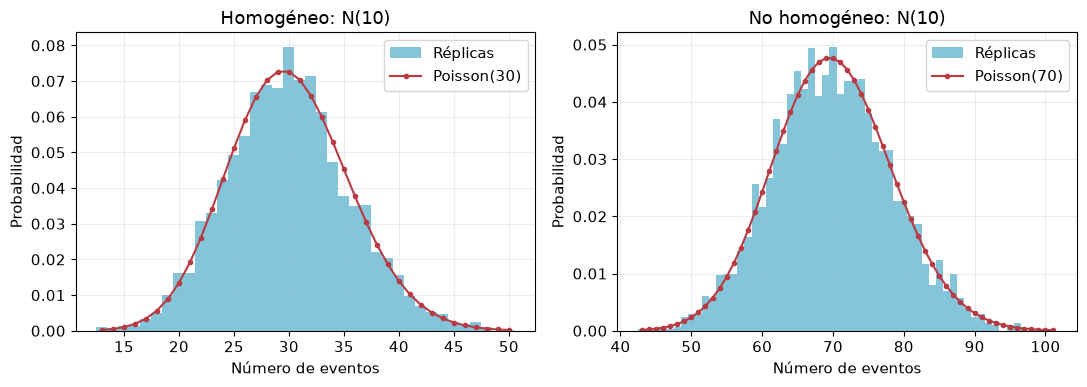

In [10]:
def intensidad(t):
    t = np.asarray(t)
    return np.where(t <= 5, t/5, 1+5*(t-5))

def acumulada(t):
    t = np.asarray(t)
    return np.where(t <= 5, t*t/10, 2.5+(t-5)+2.5*(t-5)**2)

def poisson_no_homogeneo(rng, T=10.0):
    if not np.isfinite(T) or T < 0 or T > 10:
        raise ValueError('Esta intensidad está definida para 0 <= T <= 10.')
    t, llegadas, candidatos = 0.0, [], 0
    while T > 0:
        t += exponencial(rng, 26.0)
        if t > T:
            break
        candidatos += 1
        lam = t/5 if t <= 5 else 1+5*(t-5)
        if rng.uniforme() < lam/26:
            llegadas.append(t)
    return np.array(llegadas), candidatos

lnh, candidatos = poisson_no_homogeneo(GCM(4301))
print(f'N(10)={len(lnh)}; candidatos={candidatos}; aceptación={len(lnh)/candidatos:.4f}')
print('Llegadas en [0, 10]:'); print(lnh)
t_grid = np.linspace(0, 10, 501)
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
axs[0].plot(t_grid, intensidad(t_grid), color='#b83b44')
axs[0].set(xlabel='Tiempo', ylabel='Eventos / unidad de tiempo', title='Intensidad por tramos')
axs[1].step(np.r_[0, lnh, 10], np.r_[0, np.arange(1, len(lnh)+1), len(lnh)],
            where='post', label='N(t)')
axs[1].plot(t_grid, acumulada(t_grid), '--', label='Media teórica: Lambda(t)')
axs[1].set(xlabel='Tiempo', ylabel='Conteo', title='5.3 · Poisson no homogéneo')
axs[1].legend(); fig.tight_layout(); plt.show()

rng_nh = GCM(4302)
replicas_nh = [poisson_no_homogeneo(rng_nh)[0] for _ in range(R)]
conteos_nh = np.array([len(z) for z in replicas_nh])
primera_mitad = np.array([np.sum(z <= 5) for z in replicas_nh])
resumen('N(10), 3000 réplicas', conteos_nh, 70, 70)
print(f'Media N(5)={primera_mitad.mean():.4f} (teórica 2.5)')
print(f'Media N(10)-N(5)={(conteos_nh-primera_mitad).mean():.4f} (teórica 67.5)')
assert np.all(np.diff(lnh) > 0) and np.all((lnh > 0) & (lnh <= 10))
assert np.all((intensidad(t_grid) >= 0) & (intensidad(t_grid) <= 26))
assert np.isclose(integrate.quad(lambda t: float(intensidad(t)), 0, 10, points=[5])[0], 70)
assert len(poisson_no_homogeneo(GCM(1), 0)[0]) == 0

fig, axs = plt.subplots(1, 2, figsize=(11, 4))
for ax, x, mu, title in [(axs[0], conteos_h, 30, 'Homogéneo: N(10)'),
                          (axs[1], conteos_nh, 70, 'No homogéneo: N(10)')]:
    k = np.arange(x.min(), x.max()+1)
    ax.hist(x, bins=np.arange(x.min()-0.5, x.max()+1.5), density=True,
            color='#43a6c6', alpha=0.65, label='Réplicas')
    ax.plot(k, stats.poisson.pmf(k, mu), 'o-', ms=3, color='#b83b44', label=f'Poisson({mu})')
    ax.set(title=title, xlabel='Número de eventos', ylabel='Probabilidad')
    ax.legend()
fig.tight_layout(); plt.show()

### Complemento: exponencial, Gamma y normal por el método polar
Los apartados anteriores resuelven los ejercicios 5.1 a 5.3. Este complemento cubre los objetivos adicionales enumerados en la guía.

* **Exponencial:** $X=-\log(1-U)/\lambda$, con $\lambda=2$.
* **Gamma:** para forma entera $k=3$ y tasa $\lambda=2$, sumar tres exponenciales. Esta implementación Erlang se limita explícitamente a forma entera positiva; no pretende resolver formas fraccionarias.
* **Normal estándar:** método polar descrito en la sección 3. Se descartan $S=0$ y $S\ge1$, y se aprovechan ambas normales del par aceptado. La aceptación de los pares uniformes es $\pi/4$.

Exponencial: n=1000, media=0.51272 (teórica 0.50000), varianza muestral=0.27645 (teórica 0.25000)
Error estándar teórico de la media: 0.01581; diferencia en errores estándar: 0.80
Gamma: n=1000, media=1.50495 (teórica 1.50000), varianza muestral=0.77302 (teórica 0.75000)
Error estándar teórico de la media: 0.02739; diferencia en errores estándar: 0.18
Normal estándar: n=1000, media=-0.00108 (teórica 0.00000), varianza muestral=0.99521 (teórica 1.00000)
Error estándar teórico de la media: 0.03162; diferencia en errores estándar: -0.03
Aceptación polar: 0.7657, teórica: 0.7854


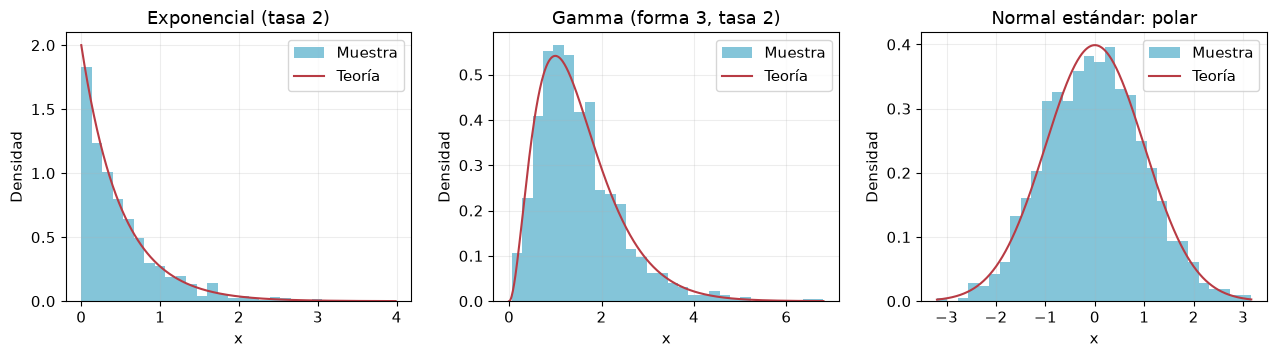

In [11]:
def gamma_entera(rng, n, k, tasa):
    if not isinstance(k, (int, np.integer)) or k < 1:
        raise ValueError('La forma k debe ser un entero positivo.')
    return np.array([sum(exponencial(rng, tasa) for _ in range(k)) for _ in range(n)])

def normal_polar(rng, n):
    salida, propuestos, aceptados = [], 0, 0
    while len(salida) < n:
        v1, v2 = 2*rng.uniforme()-1, 2*rng.uniforme()-1
        s = v1*v1+v2*v2
        propuestos += 1
        if 0 < s < 1:
            factor = math.sqrt(-2*math.log(s)/s)
            salida.extend([v1*factor, v2*factor])
            aceptados += 1
    return np.array(salida[:n]), aceptados/propuestos

rng_e = GCM(4401)
xe = np.array([exponencial(rng_e, 2) for _ in range(N)])
xg = gamma_entera(GCM(4402), N, 3, 2)
zn, ap = normal_polar(GCM(4403), N)
resumen('Exponencial', xe, 0.5, 0.25)
resumen('Gamma', xg, 1.5, 0.75)
resumen('Normal estándar', zn, 0, 1)
print(f'Aceptación polar: {ap:.4f}, teórica: {math.pi/4:.4f}')
fig, axs = plt.subplots(1, 3, figsize=(13, 3.7))
for ax, x, dist, title in [(axs[0], xe, stats.expon(scale=0.5), 'Exponencial (tasa 2)'),
                          (axs[1], xg, stats.gamma(a=3, scale=0.5), 'Gamma (forma 3, tasa 2)'),
                          (axs[2], zn, stats.norm(), 'Normal estándar: polar')]:
    grid = np.linspace(min(0, x.min()), x.max(), 500)
    ax.hist(x, bins=30, density=True, color='#43a6c6', alpha=0.65, label='Muestra')
    ax.plot(grid, dist.pdf(grid), color='#b83b44', label='Teoría')
    ax.set(title=title, xlabel='x', ylabel='Densidad'); ax.legend()
fig.tight_layout(); plt.show()

## 6. Resultados y conclusiones
Las salidas anteriores presentan muestras, momentos empíricos, referencias teóricas y las gráficas solicitadas. Para resumir el error de Monte Carlo, se muestran a continuación las diferencias entre medias empíricas y teóricas en unidades del error estándar esperado. Es un diagnóstico descriptivo, no una garantía de independencia del GCM.

In [12]:
casos = [('5.1.a', xa, ma, va), ('5.1.b', xb, 11/3, 13/18),
         ('5.1.c', xc, 7/12, 11/144), ('5.1.d', xd, md_w, vd_w),
         ('Coxian', x_cox, mc, vc), ('Poisson H', conteos_h, 30, 30),
         ('Poisson NH', conteos_nh, 70, 70)]
print(f'{"Caso":<12} {"Media simulada":>15} {"Media teórica":>15} {"Error / EE":>12}')
for nombre, x, media, varianza in casos:
    z = (x.mean()-media)/math.sqrt(varianza/len(x))
    print(f'{nombre:<12} {x.mean():15.5f} {media:15.5f} {z:12.3f}')
print('Total de observaciones de 5.1:', muestras_51.size)
print('Todas las comprobaciones deterministas se completaron sin errores.')

Caso          Media simulada   Media teórica   Error / EE
5.1.a                0.57252         0.58198       -1.061
5.1.b                3.64609         3.66667       -0.766
5.1.c                0.59426         0.58333        1.250
5.1.d                0.54619         0.56869       -1.843
Coxian               0.91168         0.88667        1.223
Poisson H           30.01133        30.00000        0.113
Poisson NH          69.88100        70.00000       -0.779
Total de observaciones de 5.1: 4000
Todas las comprobaciones deterministas se completaron sin errores.


**Interpretación de esta ejecución.** Las medias de 5.1 difieren de sus valores teóricos en menos de dos errores estándar. Los diagnósticos KS de a, b, c y d dan valores p de 0.309, 0.924, 0.460 y 0.172: no se rechaza el ajuste al nivel 0.05 en estos diagnósticos individuales. La aceptación observada en b es 48.97%, cercana al 50% esperado. En 3000 réplicas, los conteos medios homogéneo y no homogéneo son 30.011 y 69.881 frente a 30 y 70. Las diferencias son compatibles con variación de Monte Carlo bajo el modelo ideal de uniformes independientes.

1. La transformada inversa ofrece expresiones directas para a, c y Weibull; en b también existe una inversa, pero se usó rechazo para demostrar ese método. La aceptación esperada en b es 50%.
2. Los histogramas están normalizados como densidades y se comparan con **densidades**, no con acumuladas. Las diferencias puntuales respecto a la curva son esperables con 1000 observaciones.
3. La Coxian incluye la duración de la última etapa realizada, incluso cuando el trabajador decide abandonar después de ella. Las probabilidades de alcanzar cada etapa determinan su esperanza.
4. El Poisson homogéneo produce incrementos con media proporcional a la longitud del intervalo. En el no homogéneo, la media depende de la integral de la intensidad y la segunda mitad concentra la mayoría de las llegadas.
5. En la sección 5.3 la media correcta del conteo total es **70**, no la tasa máxima 26 ni 260. La cota 26 solo se usa para proponer candidatos en el rechazo temporal.
6. El periodo completo y los diagnósticos del GCM permiten evaluar su uso en esta práctica, pero no eliminan sus limitaciones estructurales. Los resultados son reproducibles; al modificar las semillas variarán las muestras y los errores empíricos.

## 7. Bibliografía
* Guía suministrada: **FO-DOC-112, Laboratorio de Simulación Computacional, Práctica 04: Generación de Variables Aleatorias Continuas**, Universidad de los Llanos, Ángel Alfonso Cruz Roa, 25 de septiembre de 2024, pp. 1-3. Fuente de los enunciados y fórmulas transcritas.
* Ross, Sheldon. *Simulation*. Fifth Edition. Pearson, 2013. Referencia bibliográfica indicada en la guía de laboratorio.